In [1]:
import os
import torch
torch.set_default_dtype(torch.double)

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from nflows import transforms

# diffeomorphisms
from src.diffeomorphisms.composition import CompositionDiffeomorphism
from src.diffeomorphisms.vector.transform import TransformVectorDiffeomorphism
from src.diffeomorphisms.vector.product_starflow import ProductStarFlowVectorDiffeomorphism

# dimension reduction
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver  

# distributions
from src.distributions.star_gaussians.multi_inverse_linear_norm_gaussian import MultiInverseLinearStarNormGaussianDistribution
from src.distributions.starflows.products.diagonal import StarDiagonalFlowDistribution

# embeddings
from src.embedding.hyperbolic_gromov_monge import HyperbolicGromovMongeEmbedding

# manifolds
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.manifolds.isometrized_euclidean.vector import l2IsometrizedVectorEuclidean

# training
from src.training.diffeomorphic_decoder import DiffeomorphicDecoderTraining
from src.training.hyperbolic_gromov_monge_embedding import HyperbolicGromovMongeEmbeddingTraining
from src.training.latent_star_gaussian import LatentStarGaussianTraining
from src.training.latent_starflow import LatentStarFlowTraining

# transforms
from src.transforms.vector.parity.simple_tanh import SimpleTanhParityVectorTransform
from src.transforms.vector.linear.lower_triangular import LowerTriangularLinearVectorTransform
from src.transforms.vector.linear.upper_triangular import UpperTriangularLinearVectorTransform

results_folder = os.path.join("results", "tree", "four_phase")
# fix seed
torch.manual_seed(31)

### Construct data set ###

Data shape: torch.Size([2000, 3])


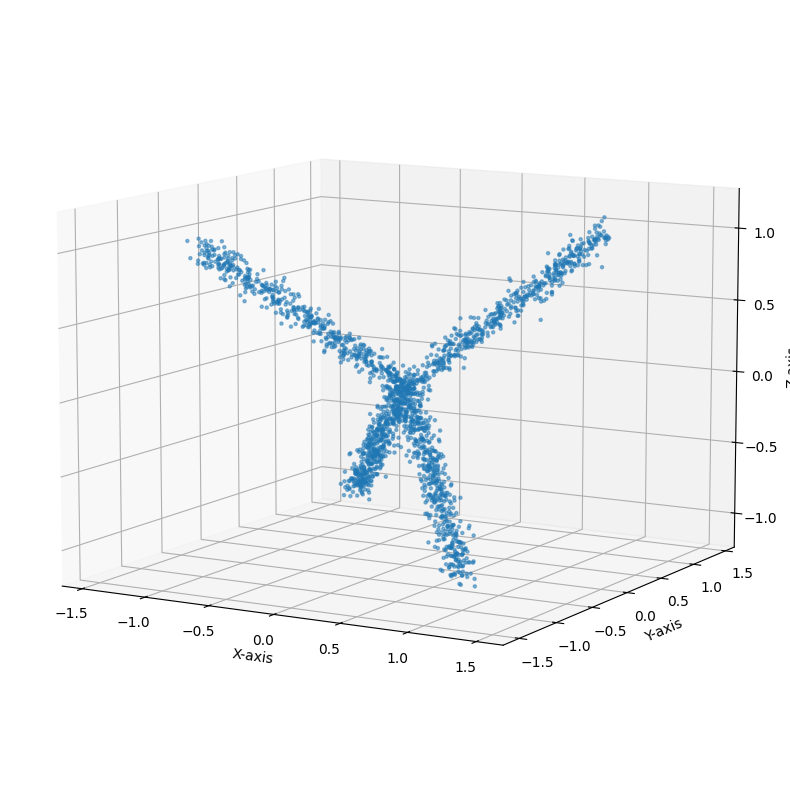

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)
print("Data shape:", data.shape)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data.png"))
plt.show()

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.shape[0]

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime = self.data[idx2]
        return x, x_prime
    
# create dataset and dataloader
pair_dataset = RandomPairDataset(data)
dataloader = DataLoader(pair_dataset, batch_size=128, shuffle=True)

### Stage 1: Learn an Embedding ###

In [4]:
# construct Gromov-Monge Embedding in Hyperbolic Space
class SimpleHyperbolicGromovMongeEmbedding(HyperbolicGromovMongeEmbedding):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleHyperbolicGromovMongeEmbedding, self).__init__(self.create_nn_model(input_dim, hidden_dim, output_dim), output_dim=output_dim)
    
    def create_nn_model(self, input_dim, hidden_dim, output_dim):
        return torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, output_dim)
        )

# instantiate Gromov-Monge Embedding Trainer
input_dim = 3
hidden_dim = 20
output_dim = 2  # we will embed into 2D hyperbolic space

hgme_trainer = HyperbolicGromovMongeEmbeddingTraining(SimpleHyperbolicGromovMongeEmbedding(input_dim, hidden_dim, output_dim), reg_param=1e-2, lr=1e-3)

In [5]:
# construct train loop
num_epochs = 50
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for x, x_prime in dataloader:
        loss = hgme_trainer.train_step(x, x_prime)
        epoch_loss += loss * x.size(0)
    epoch_loss /= len(pair_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}")

emb = hgme_trainer.emb

Epoch 1/50, Loss: 1.169991
Epoch 2/50, Loss: 0.820355
Epoch 3/50, Loss: 0.367069
Epoch 4/50, Loss: 0.075657
Epoch 5/50, Loss: 0.038916
Epoch 6/50, Loss: 0.026874
Epoch 7/50, Loss: 0.024009
Epoch 8/50, Loss: 0.022433
Epoch 9/50, Loss: 0.021533
Epoch 10/50, Loss: 0.020991
Epoch 11/50, Loss: 0.019848
Epoch 12/50, Loss: 0.018844
Epoch 13/50, Loss: 0.018597
Epoch 14/50, Loss: 0.018788
Epoch 15/50, Loss: 0.018925
Epoch 16/50, Loss: 0.018568
Epoch 17/50, Loss: 0.018150
Epoch 18/50, Loss: 0.017552
Epoch 19/50, Loss: 0.018897
Epoch 20/50, Loss: 0.018101
Epoch 21/50, Loss: 0.017236
Epoch 22/50, Loss: 0.016976
Epoch 23/50, Loss: 0.017091
Epoch 24/50, Loss: 0.017625
Epoch 25/50, Loss: 0.017700
Epoch 26/50, Loss: 0.017647
Epoch 27/50, Loss: 0.017209
Epoch 28/50, Loss: 0.016622
Epoch 29/50, Loss: 0.017046
Epoch 30/50, Loss: 0.017601
Epoch 31/50, Loss: 0.017472
Epoch 32/50, Loss: 0.017848
Epoch 33/50, Loss: 0.016846
Epoch 34/50, Loss: 0.016956
Epoch 35/50, Loss: 0.016946
Epoch 36/50, Loss: 0.017535
E

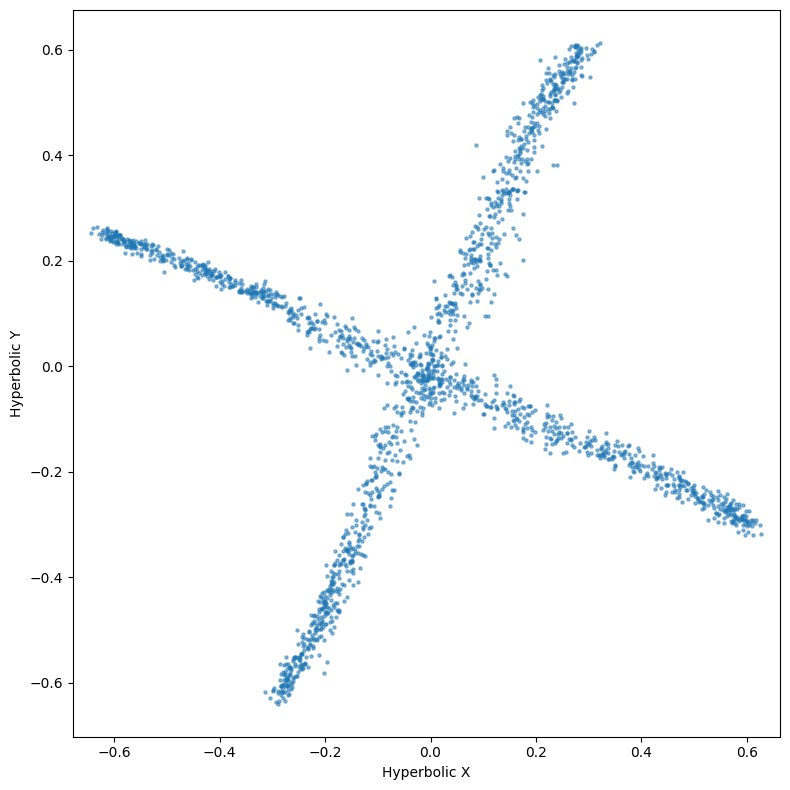

In [6]:
# visualize embeddings
with torch.no_grad():
    embeddings = emb(data).cpu().numpy()
plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"emb_final.png"))
plt.show()

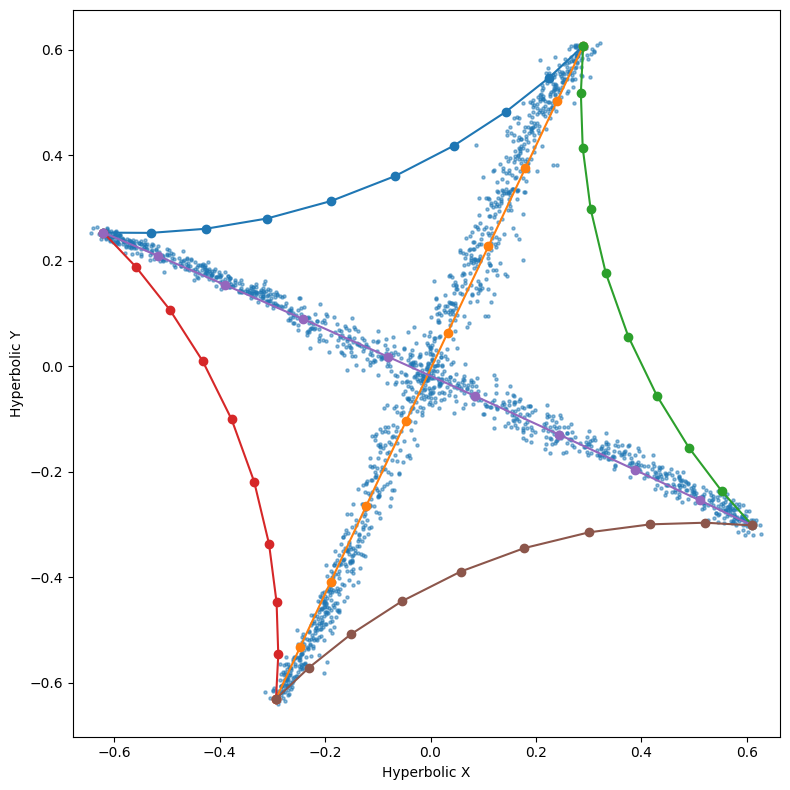

In [7]:
# interpolate between cluster centers
plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
for i in range(data_clusters.shape[0]):
    for j in range(i + 1, data_clusters.shape[0]):
        center1 = data_clusters[i].unsqueeze(0)
        center2 = data_clusters[j].unsqueeze(0)
        t_values = torch.linspace(0, 1, steps=10)
        with torch.no_grad():
            interp_points = emb.interpolate(center1, center2, t_values)[0]
        # interp_points = interp_points.cpu().numpy()
        plt.plot(interp_points[:, 0], interp_points[:, 1], marker='o')
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"emb_final_geodesics.png"))
plt.show()

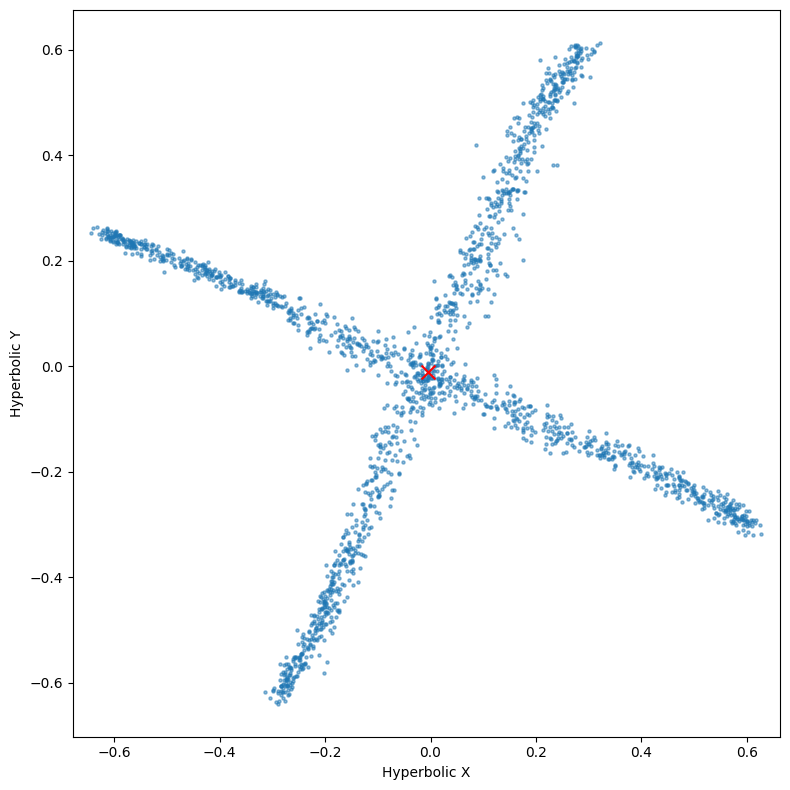

In [8]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    barycentre = emb.barycentre(data)

plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
plt.scatter(barycentre[0].item(), barycentre[1].item(), color='red', marker='x', s=100, label='Barycentre')
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"emb_final_bary.png"))
plt.show()  

In [9]:
# translate origin with isometr
# check that distances are preserved I: compute old distances
with torch.no_grad():
    dist_emb = emb.distance(data_clusters[1:], data_clusters[:-1])

# update origin
emb.set_origin(barycentre)

# check that distances are preserved II: compute new distances
with torch.no_grad():
    dist_emb_centered = emb.distance(data_clusters[1:], data_clusters[:-1])
print("Pairwise distance matrix in embedding space between cluster centers:")
print((dist_emb - dist_emb_centered).abs().max())  # should be close to zero

Pairwise distance matrix in embedding space between cluster centers:
tensor(4.4409e-16)


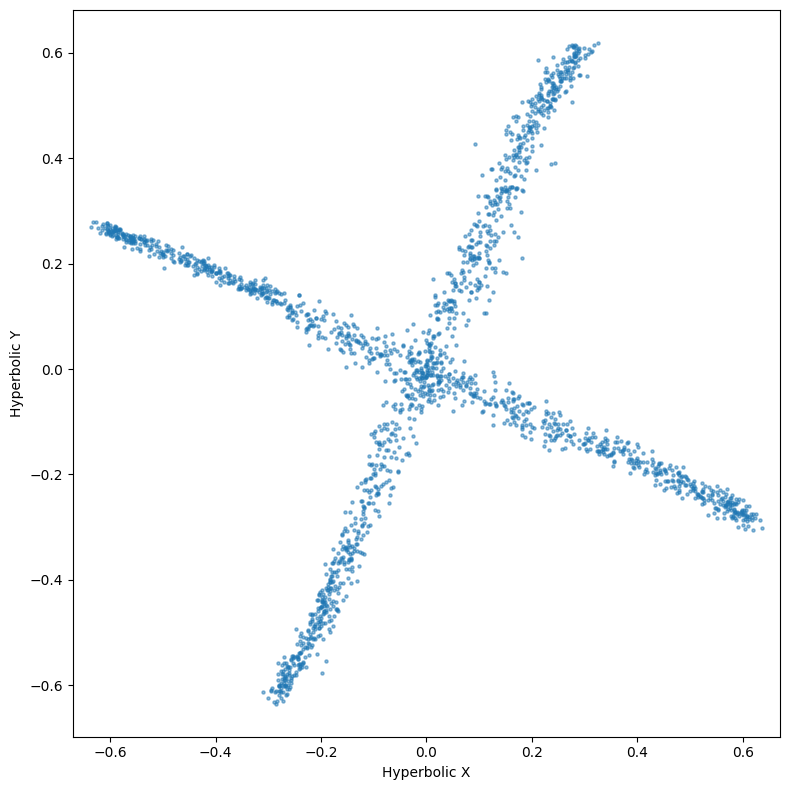

In [10]:
# compute embeddings again after centering
with torch.no_grad():
    embeddings_centered = emb(data)
    
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"emb_final_centered.png"))
plt.show()

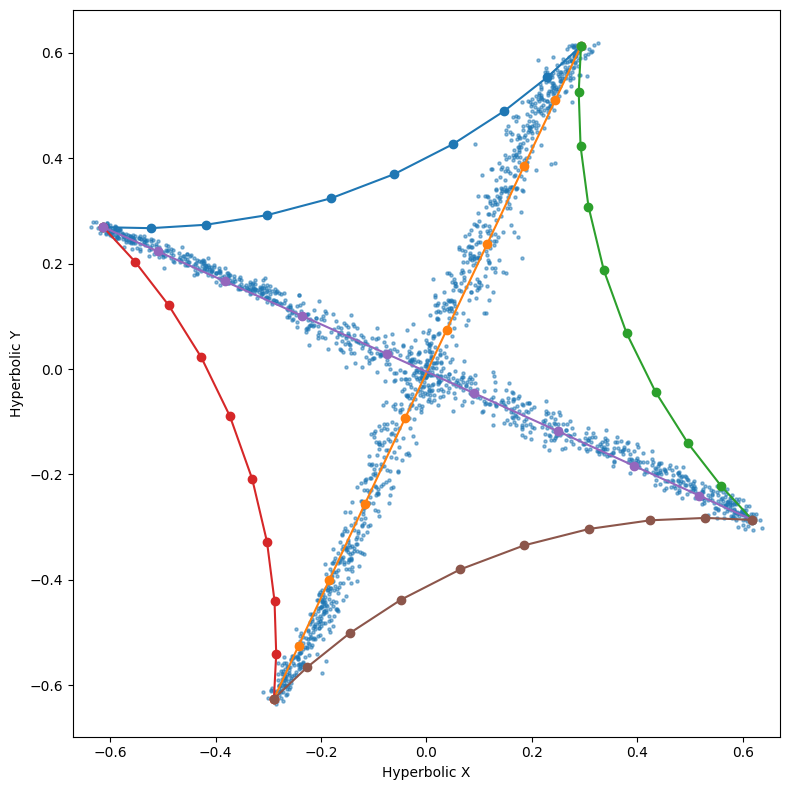

In [11]:
# interpolate between cluster centers after centering
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        center1 = data_clusters[i].unsqueeze(0)
        center2 = data_clusters[j].unsqueeze(0)
        t_values = torch.linspace(0, 1, steps=10)
        with torch.no_grad():
            interp_points_centered = emb.interpolate(center1, center2, t_values)[0]
        plt.plot(interp_points_centered[:, 0], interp_points_centered[:, 1], marker='o')
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"emb_final_centered_geodesics.png"))
plt.show()

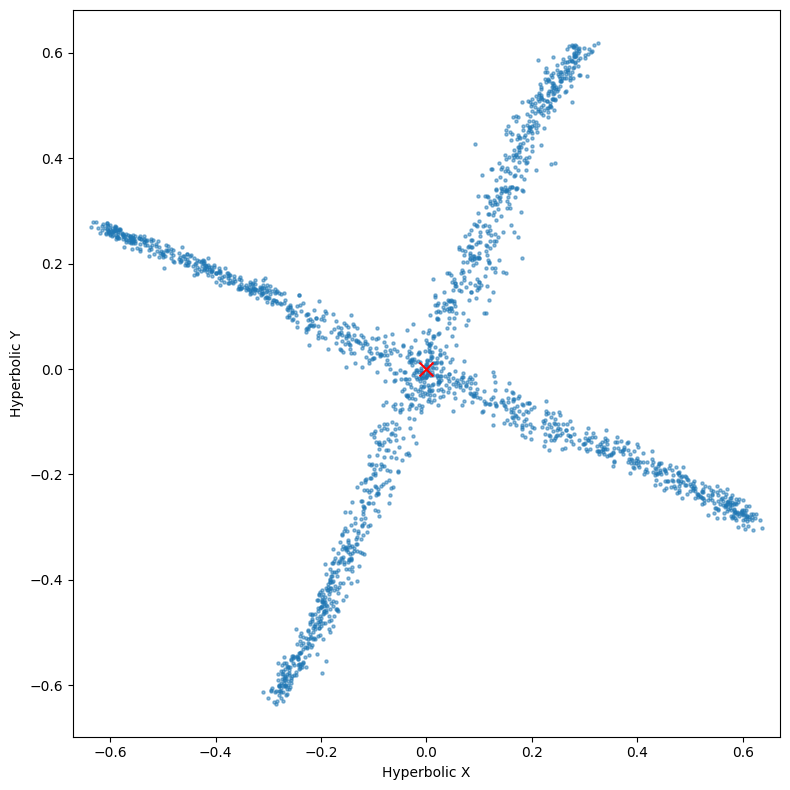

Distance between barycentres before and after centering:
2.7035918211879493e-07


In [12]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    barycentre_centered = emb.barycentre(data)

plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
plt.scatter(barycentre_centered[0].item(), barycentre_centered[1].item(), color='red', marker='x', s=100, label='Barycentre')
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"emb_final_centered_bary.png"))
plt.show()  

# check difference between barycentres
print("Distance between barycentres before and after centering:")
translated_barycentre = emb.translate(barycentre, barycentre)
print((translated_barycentre - barycentre_centered).norm().item())  # should be close to zero

### Stage 2: Learn an Embedding-informed Diffeomorphic Decoder ###

In [13]:
# construct transform diffeomorphism
class SimpleTransformVectorDiffeomorphism(TransformVectorDiffeomorphism):
    def __init__(self, dim, hidden_dim, n_flows):
        super(SimpleTransformVectorDiffeomorphism, self).__init__(dim, self.create_transform(dim, hidden_dim, n_flows))

    def create_transform(self, dim, hidden_dim, n_flows):
        transforms_list = []
        for i in range(n_flows):
            transforms_list.append(UpperTriangularLinearVectorTransform(dim))
            transforms_list.append(LowerTriangularLinearVectorTransform(dim))
            transforms_list.append(SimpleTanhParityVectorTransform(dim, hidden_dim, parity=i))
        transforms_list.append(UpperTriangularLinearVectorTransform(dim))
        transforms_list.append(LowerTriangularLinearVectorTransform(dim))
        transform = transforms.CompositeTransform(transforms_list)
        return transform

# construct transform diffeomorphism trainer
dim = 3
hidden_dim = 8
n_flows = 2
    
# instantiate GME-informed star flow
diffeo_decoder_trainer = DiffeomorphicDecoderTraining(emb, SimpleTransformVectorDiffeomorphism(dim, hidden_dim, n_flows), reg_param=1e-4, sigma=sigma, lr=1e-3)

In [14]:
# construct train loop for the decoding diffeomorphism
num_epochs_flow = 500
for epoch in range(num_epochs_flow):
    epoch_loss = 0.0
    for x, _ in dataloader:
        loss = diffeo_decoder_trainer.train_step(x)
        epoch_loss += loss * x.size(0)
    epoch_loss /= len(pair_dataset)
    if (epoch + 1) % (num_epochs_flow // 10) == 0 or epoch == 0:
        print(f"Flow Epoch {epoch+1}/{num_epochs_flow}, Loss: {epoch_loss:.6f}")

phi = diffeo_decoder_trainer.phi

Flow Epoch 1/500, Loss: 0.445146
Flow Epoch 50/500, Loss: 0.040244
Flow Epoch 100/500, Loss: 0.027843
Flow Epoch 150/500, Loss: 0.024806
Flow Epoch 200/500, Loss: 0.020162
Flow Epoch 250/500, Loss: 0.016836
Flow Epoch 300/500, Loss: 0.014289
Flow Epoch 350/500, Loss: 0.006860
Flow Epoch 400/500, Loss: 0.003509
Flow Epoch 450/500, Loss: 0.002939
Flow Epoch 500/500, Loss: 0.002751


In [15]:
# construct manifold from learned diffeomorphism
phi_manifold = StandardPullbackVectorEuclidean(phi)
# construct iso_manifold
iso_phi_manifold = l2IsometrizedVectorEuclidean(phi_manifold)

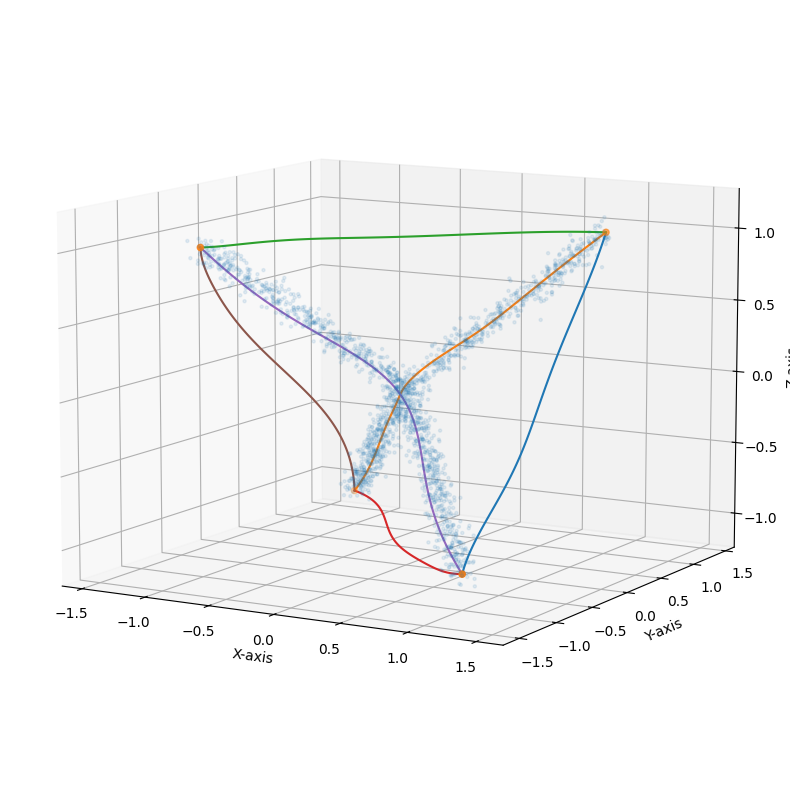

In [16]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    phi_geodesics = iso_phi_manifold.geodesic(data_clusters[None], data_clusters[None], t)

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(phi_geodesics[0, i, j, :, 0].numpy(), phi_geodesics[0, i, j, :, 1].numpy(), phi_geodesics[0, i, j, :, 2].numpy())
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_phi_geodesics.png"))
plt.show()

iteration 1 | error = 0.003916018952788246
iteration 2 | error = 0.001756075227199007
iteration 3 | error = 0.0007879450121619006
iteration 4 | error = 0.0003537374412459243
iteration 5 | error = 0.0001588843811511735
iteration 6 | error = 7.13969533348802e-05
gradient descent was terminated after reaching a error 7.13969533348802e-05 in 6 iterations
Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


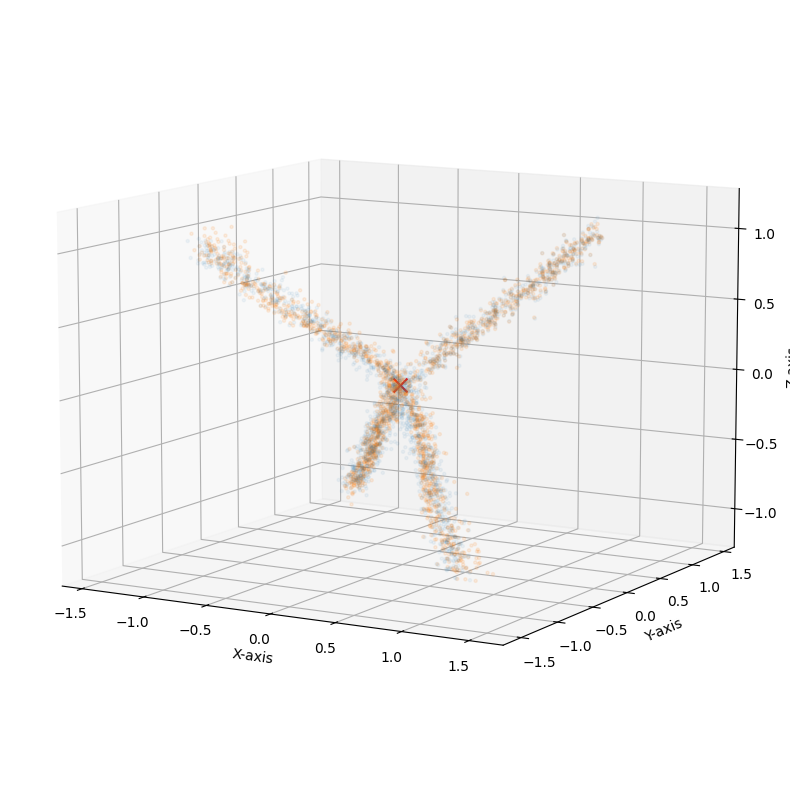

Mean reconstruction error after compression: 0.058915558983890365


In [17]:
# compute data barycentre
phi_barycentre_data = iso_phi_manifold.barycentre(data, tol=1e-4, max_iter=20, step_size=0.5)
# tangent space PCA to find principal directions at data barycentre
l2_pga_solver_phi_bary = l2TangentSpacePCAVectorSolver(data, iso_phi_manifold, phi_barycentre_data)
# compute principal directions
_, phi_compressed_data, _ = l2_pga_solver_phi_bary.solve(2)

# plot compressed data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(phi_compressed_data[:, 0].numpy(), phi_compressed_data[:, 1].numpy(), phi_compressed_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(phi_barycentre_data[0].item(), phi_barycentre_data[1].item(), phi_barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_phi_compressed.png"))
plt.show()

# compute error between original data and compressed data
rel_error = (torch.norm(data - phi_compressed_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
print("Mean reconstruction error after compression:", rel_error)

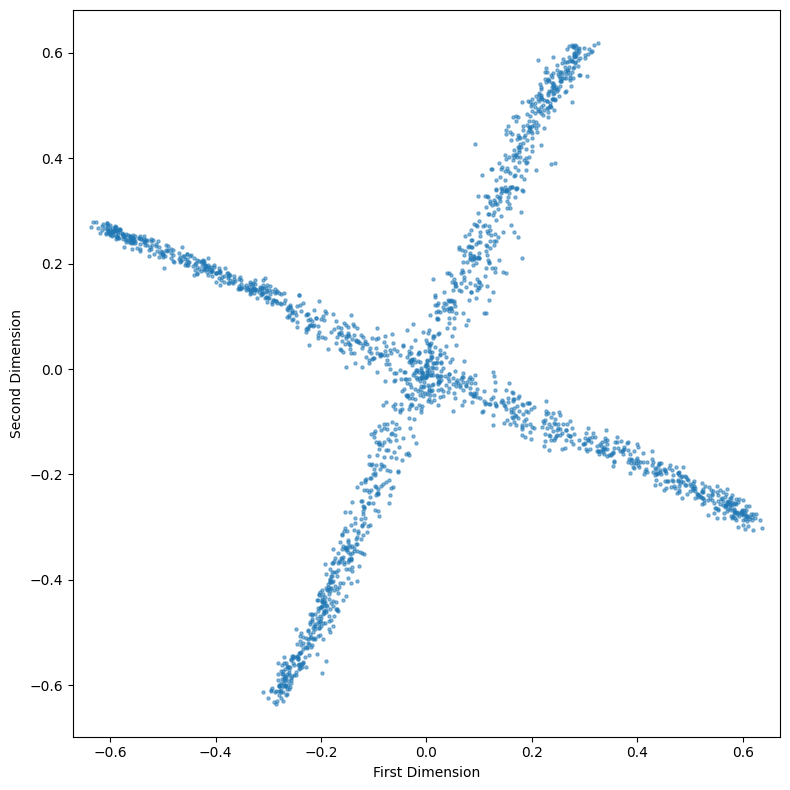

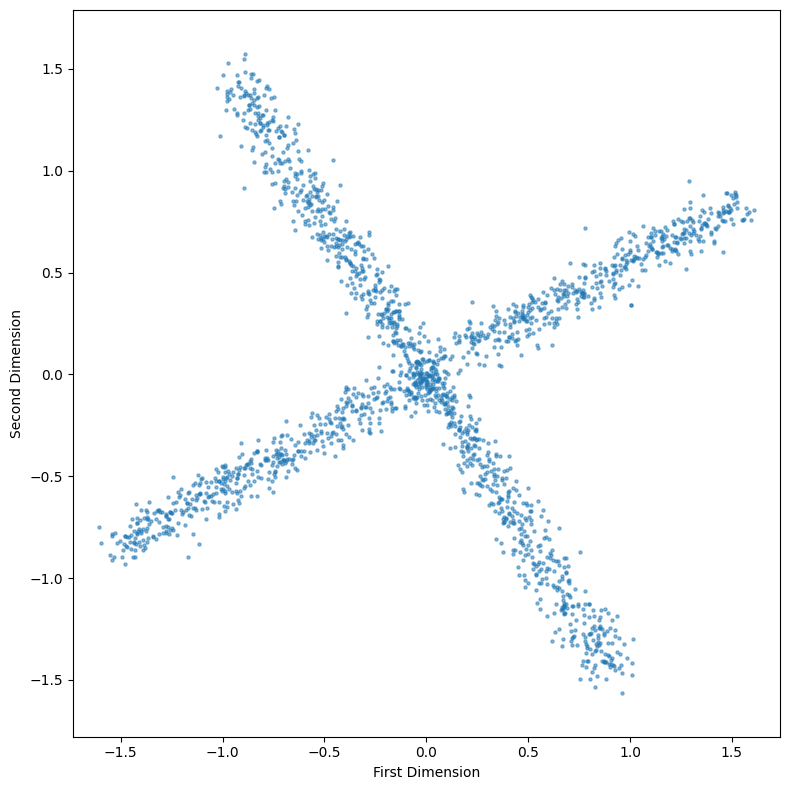

In [18]:
# compare embeddings
phi_pca_embedding = l2_pga_solver_phi_bary.get_embedding(2)

# plot embeddings comparison in different figures (because different spaces)
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5, label='HGME Embedding')
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.axis('equal')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(phi_pca_embedding[:, 0], phi_pca_embedding[:, 1], s=5, alpha=0.5, label='Tangent Space PCA Embedding')
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"phi_emb_comparison.png"))
plt.show()

### Stage 3: Learn a Star Gaussian Distribution ###

In [19]:
# construct bimodal Star Gaussian 
num_radials = 2
star_gaussian_trainer = LatentStarGaussianTraining(phi, MultiInverseLinearStarNormGaussianDistribution(2, num_radials=num_radials), lr=1e-2)

In [20]:
# construct training loop for the radial function
num_epochs_flow = 500
for epoch in range(num_epochs_flow):
    epoch_loss = 0.0
    for x, _ in dataloader:
        loss = star_gaussian_trainer.train_step(x)
        epoch_loss += loss * x.size(0)
    epoch_loss /= len(pair_dataset)
    if (epoch + 1) % (num_epochs_flow // 10) == 0 or epoch == 0:
        print(f"Flow Epoch {epoch+1}/{num_epochs_flow}, Loss: {epoch_loss:.6f}")

psi = star_gaussian_trainer.psi
phi_psi = CompositionDiffeomorphism([phi, psi]) # star_gaussian_trainer.phi_psi

star_gaussian = star_gaussian_trainer.star

Flow Epoch 1/500, Loss: 5.607853
Flow Epoch 50/500, Loss: 0.962574
Flow Epoch 100/500, Loss: 0.775160
Flow Epoch 150/500, Loss: 0.699546
Flow Epoch 200/500, Loss: 0.421296
Flow Epoch 250/500, Loss: 0.287215
Flow Epoch 300/500, Loss: 0.246298
Flow Epoch 350/500, Loss: 0.223813
Flow Epoch 400/500, Loss: 0.218691
Flow Epoch 450/500, Loss: 0.210180
Flow Epoch 500/500, Loss: 0.205604


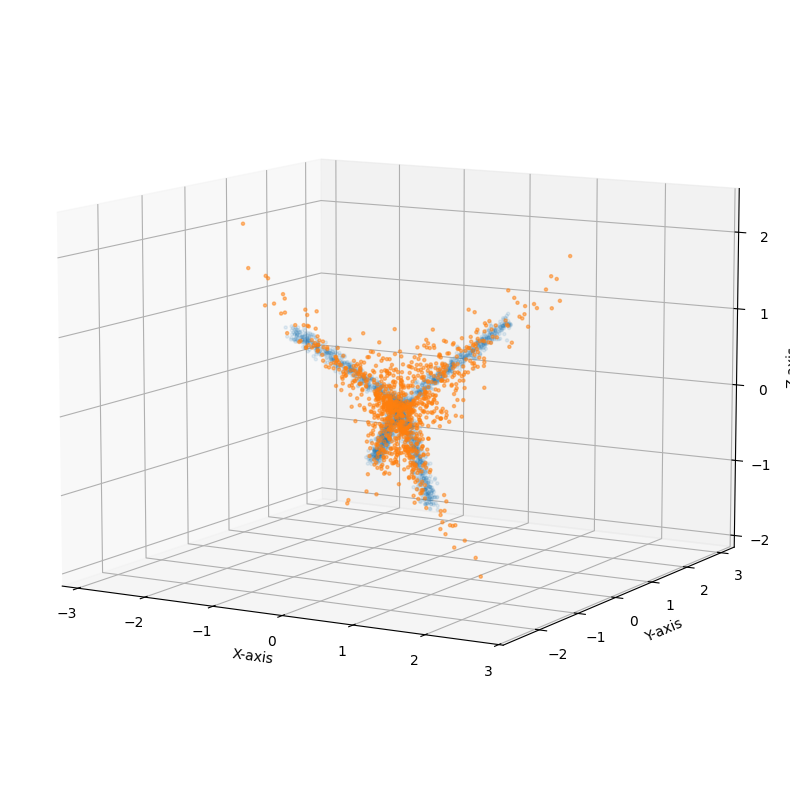

In [21]:
with torch.no_grad():
    latent_samples = star_gaussian_trainer.star.sample(1000)
    phi_x_samples = torch.zeros(1000, 3)  # placeholder for conditioning variable, not used in this case
    phi_x_samples[:,:2] = latent_samples  # set the first two dimensions to the sampled latent variables
    samples = star_gaussian_trainer.phi.inverse(phi_x_samples)  # decode the samples through the learned diffeomorphism

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.1, label='Data')
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], s=5, alpha=0.5, label='Samples')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"starflow_samples_epoch_{epoch+1}.png"))
plt.show()

In [22]:
# construct manifold from learned flow
phi_psi_manifold = StandardPullbackVectorEuclidean(phi_psi)
# construct iso_manifold 
iso_phi_psi_manifold = l2IsometrizedVectorEuclidean(phi_psi_manifold)

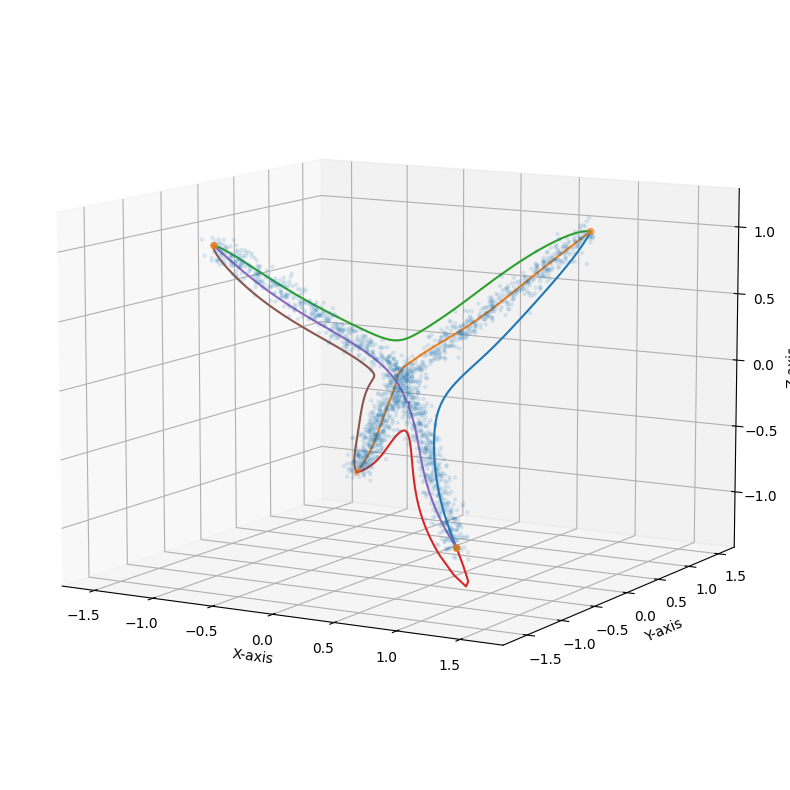

In [23]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    phi_psi_geodesics = iso_phi_psi_manifold.geodesic(data_clusters[None], data_clusters[None], t)

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(phi_psi_geodesics[0, i, j, :, 0].numpy(), phi_psi_geodesics[0, i, j, :, 1].numpy(), phi_psi_geodesics[0, i, j, :, 2].numpy())
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_phi_psi_geodesics.png"))
plt.show()

### Stage 4: Learn a StarFlow ###

In [24]:
starflow_trainer = LatentStarFlowTraining(StarDiagonalFlowDistribution(input_dim, phi.transform, star_gaussian), lr=1e-3)

In [25]:
# construct training loop for the radial function
num_epochs_starflow = 500
for epoch in range(num_epochs_starflow):
    epoch_loss = 0.0
    for x, _ in dataloader:
        loss = starflow_trainer.train_step(x)
        epoch_loss += loss * x.size(0)
    epoch_loss /= len(pair_dataset)
    if (epoch + 1) % (num_epochs_starflow // 10) == 0 or epoch == 0:
        print(f"StarFlow Epoch {epoch+1}/{num_epochs_starflow}, Loss: {epoch_loss:.6f}")

starflow = ProductStarFlowVectorDiffeomorphism(3, starflow_trainer.starflow) # starflow_trainer.diffeo

StarFlow Epoch 1/500, Loss: 1.098431
StarFlow Epoch 50/500, Loss: 0.288034
StarFlow Epoch 100/500, Loss: -0.090743
StarFlow Epoch 150/500, Loss: -0.418710
StarFlow Epoch 200/500, Loss: -0.679159
StarFlow Epoch 250/500, Loss: -0.851228
StarFlow Epoch 300/500, Loss: -0.904693
StarFlow Epoch 350/500, Loss: -0.934172
StarFlow Epoch 400/500, Loss: -0.953267
StarFlow Epoch 450/500, Loss: -0.970807
StarFlow Epoch 500/500, Loss: -0.984999


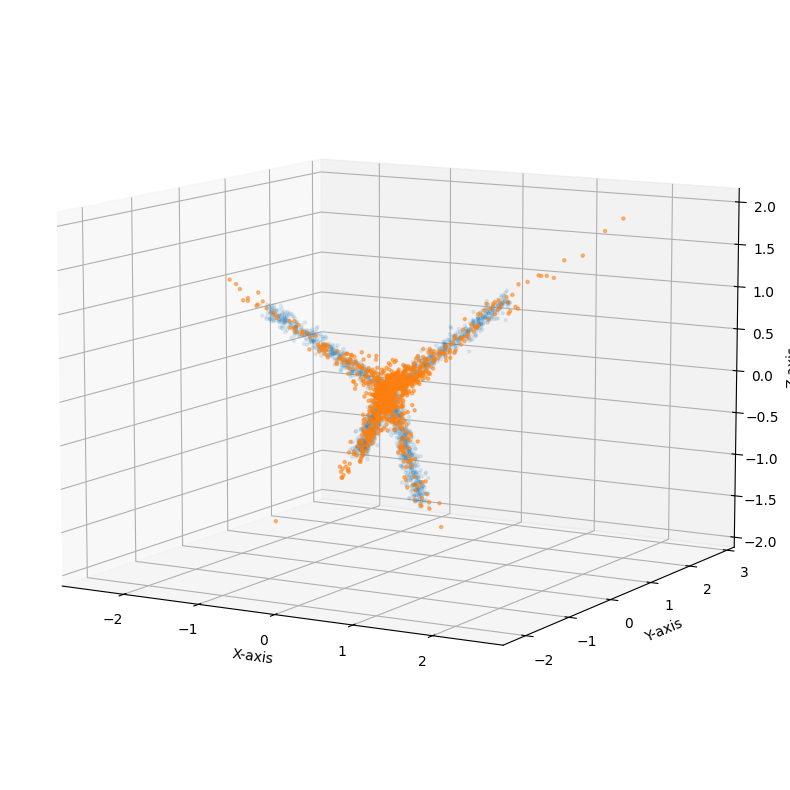

In [26]:
with torch.no_grad():
    samples = starflow_trainer.starflow.sample(1000)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.1, label='Data')
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], s=5, alpha=0.5, label='Samples')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"starflow_samples_epoch_{epoch+1}.png"))
plt.show()

In [27]:
# construct manifold from learned flow
starflow_manifold = StandardPullbackVectorEuclidean(starflow)
# construct iso_manifold 
iso_starflow_manifold = l2IsometrizedVectorEuclidean(starflow_manifold)

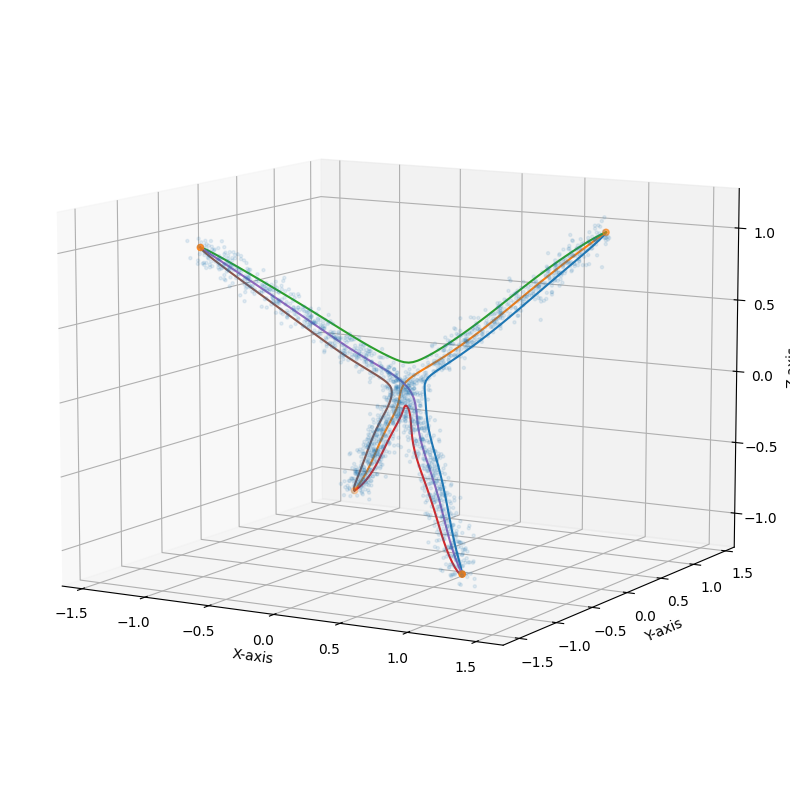

In [28]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    starflow_geodesics = iso_starflow_manifold.geodesic(data_clusters[None], data_clusters[None], t)

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(starflow_geodesics[0, i, j, :, 0].numpy(), starflow_geodesics[0, i, j, :, 1].numpy(), starflow_geodesics[0, i, j, :, 2].numpy())
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_starflow_geodesics.png"))
plt.show()

iteration 1 | error = 0.007774754289474004
iteration 2 | error = 0.004457387019087402
iteration 3 | error = 0.0030303219858859917
iteration 4 | error = 0.002749443322345812
iteration 5 | error = 0.0022552368264651588
iteration 6 | error = 0.0014287614887983566
iteration 7 | error = 0.0006569158990468786
iteration 8 | error = 0.0006081771627325545
iteration 9 | error = 0.000608177162622153
iteration 10 | error = 0.0006081771625116818
iteration 11 | error = 0.0006081771624011799
iteration 12 | error = 0.0006081771622908572
iteration 13 | error = 0.0006081771621803929
iteration 14 | error = 0.0006081771620699906
iteration 15 | error = 0.000608177161959557
iteration 16 | error = 0.000608177161849179
iteration 17 | error = 0.0006081771617387367
iteration 18 | error = 0.0006081771616282923
iteration 19 | error = 0.0006081771615178546
iteration 20 | error = 0.0006081771614073798
gradient descent was terminated after reaching a error 0.0006081771614073798 in 20 iterations
Computing rank 2 appr

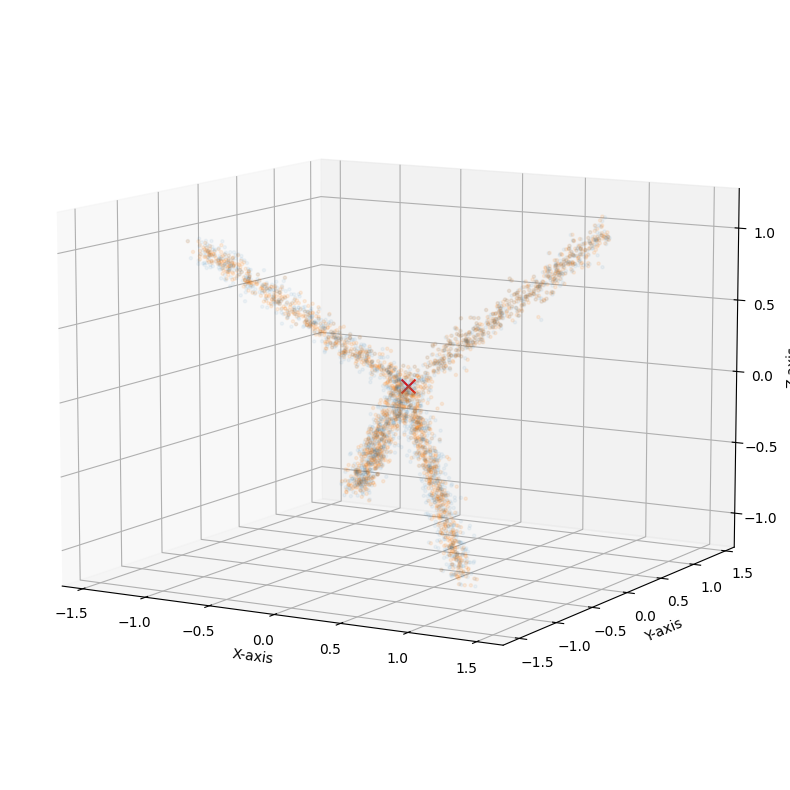

Mean reconstruction error after compression: 0.049306664336075424


In [29]:
# compute data barycentre
starflow_barycentre_data = iso_starflow_manifold.barycentre(data, tol=1e-4, max_iter=20, step_size=0.5)
# tangent space PCA to find principal directions at data barycentre
l2_pga_solver_starflow_bary = l2TangentSpacePCAVectorSolver(data, iso_starflow_manifold, starflow_barycentre_data)
# compute principal directions
_, starflow_compressed_data, _ = l2_pga_solver_starflow_bary.solve(2)

# plot compressed data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(starflow_compressed_data[:, 0].numpy(), starflow_compressed_data[:, 1].numpy(), starflow_compressed_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(starflow_barycentre_data[0].item(), starflow_barycentre_data[1].item(), starflow_barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_starflow_compressed.png"))
plt.show()

# compute error between original data and compressed data
rel_error = (torch.norm(data - starflow_compressed_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
print("Mean reconstruction error after compression:", rel_error)

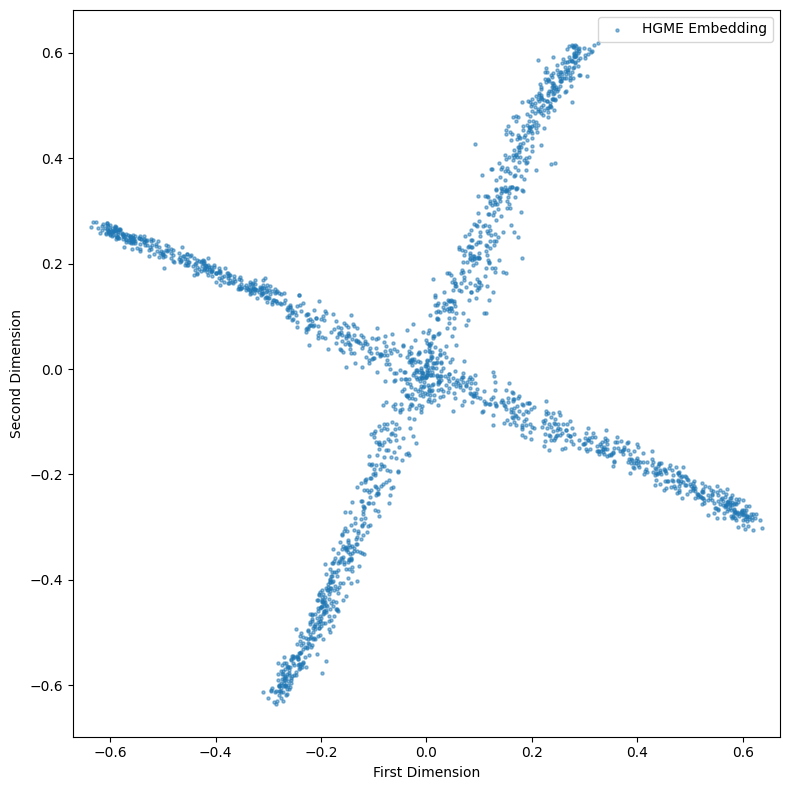

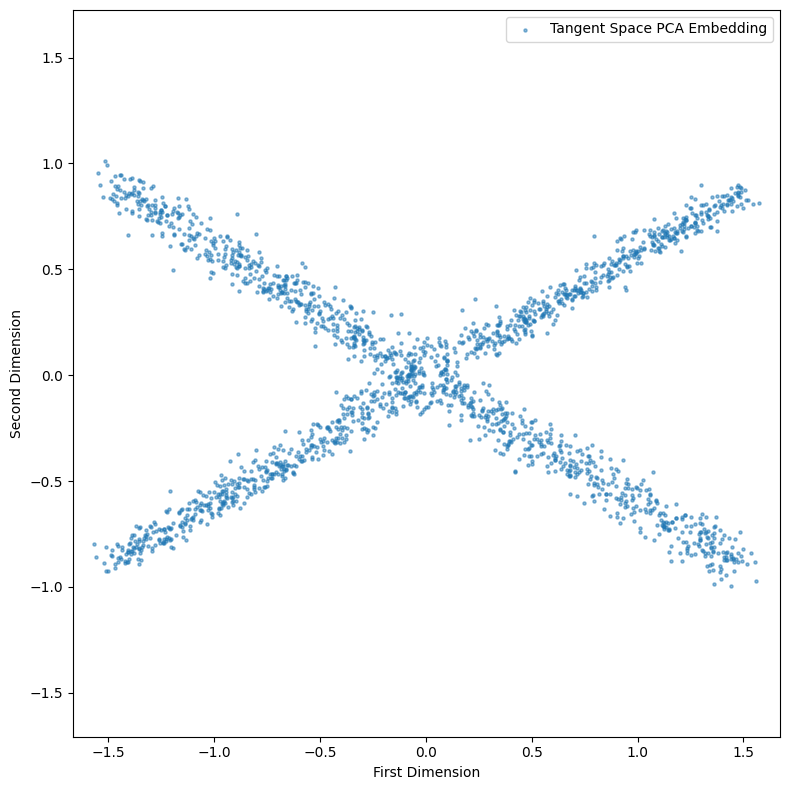

In [30]:
# compare embeddings
starflow_pca_embedding = l2_pga_solver_starflow_bary.get_embedding(2)

# plot embeddings comparison in different figures (because different spaces)
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5, label='HGME Embedding')
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(starflow_pca_embedding[:, 0], starflow_pca_embedding[:, 1], s=5, alpha=0.5, label='Tangent Space PCA Embedding')
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"starflow_emb_comparison.png"))
plt.show()